In [18]:
!pip install torch torchvision matplotlib tqdm

In [19]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torchvision.utils import make_grid
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [20]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
!tar -xvf facades.tar.gz

--2026-06-18 10:54:12--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30168306 (29M) [application/x-gzip]
Saving to: ‘facades.tar.gz.1’

facades.tar.gz.1    100%[===================>]  28.77M  4.67MB/s    in 8.1s    

2026-06-18 10:54:20 (3.54 MB/s) - ‘facades.tar.gz.1’ saved [30168306/30168306]

facades/
facades/test/
facades/test/27.jpg
facades/test/5.jpg
facades/test/72.jpg
facades/test/1.jpg
facades/test/10.jpg
facades/test/100.jpg
facades/test/101.jpg
facades/test/102.jpg
facades/test/103.jpg
facades/test/104.jpg
facades/test/105.jpg
facades/test/106.jpg
facades/test/11.jpg
facades/test/12.jpg
facades/test/13.jpg
facades/test/14.jpg
facades/test/15.jpg
facades/test/16.jpg
facades/test/17.jpg
facades/test/18.jpg
facade

In [21]:
from PIL import Image
import os

class FacadesDataset(torch.utils.data.Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.images = os.listdir(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.root_dir,
            self.images[idx]
        )

        img = Image.open(img_path)

        w, h = img.size

        input_img = img.crop((0,0,w//2,h))
        target_img = img.crop((w//2,0,w,h))

        if self.transform:
            input_img = self.transform(input_img)
            target_img = self.transform(target_img)

        return input_img, target_img

In [22]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [23]:
train_dataset = FacadesDataset(
    "facades/train",
    transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

In [24]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128,64,4,2,1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64,3,4,2,1
            ),

            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

In [25]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,1,4,1,1),
            nn.Sigmoid()
        )

    def forward(self,x,y):

        combined = torch.cat([x,y],1)

        return self.model(combined)

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [27]:
adversarial_loss = nn.BCELoss()

l1_loss = nn.L1Loss()

In [28]:
g_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

d_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5,0.999)
)

In [29]:
epochs = 10

for epoch in range(epochs):

    for input_img,target_img in train_loader:

        input_img = input_img.to(device)
        target_img = target_img.to(device)

        real = torch.ones(
            input_img.size(0),1,63,63
        ).to(device)

        fake = torch.zeros(
            input_img.size(0),1,63,63
        ).to(device)

        # Train Generator

        g_optimizer.zero_grad()

        generated = generator(input_img)

        pred = discriminator(
            input_img,
            generated
        )

        g_loss = (
            adversarial_loss(pred,real)
            +100*l1_loss(
                generated,
                target_img
            )
        )

        g_loss.backward()
        g_optimizer.step()

        # Train Discriminator

        d_optimizer.zero_grad()

        real_loss = adversarial_loss(
            discriminator(
                input_img,
                target_img
            ),
            real
        )

        fake_loss = adversarial_loss(
            discriminator(
                input_img,
                generated.detach()
            ),
            fake
        )

        d_loss = (
            real_loss +
            fake_loss
        )/2

        d_loss.backward()
        d_optimizer.step()

    print(
        f"Epoch {epoch+1} | "
        f"G Loss: {g_loss.item():.4f} | "
        f"D Loss: {d_loss.item():.4f}"
    )

Epoch 1 | G Loss: 42.8682 | D Loss: 0.4471
Epoch 2 | G Loss: 43.6816 | D Loss: 0.3269
Epoch 3 | G Loss: 33.1827 | D Loss: 0.3646
Epoch 4 | G Loss: 47.0352 | D Loss: 0.1305
Epoch 5 | G Loss: 42.0650 | D Loss: 0.3305
Epoch 6 | G Loss: 38.9012 | D Loss: 0.2628
Epoch 7 | G Loss: 53.0587 | D Loss: 0.1232
Epoch 8 | G Loss: 47.0366 | D Loss: 0.1690
Epoch 9 | G Loss: 41.9358 | D Loss: 0.1740
Epoch 10 | G Loss: 35.6776 | D Loss: 0.2950


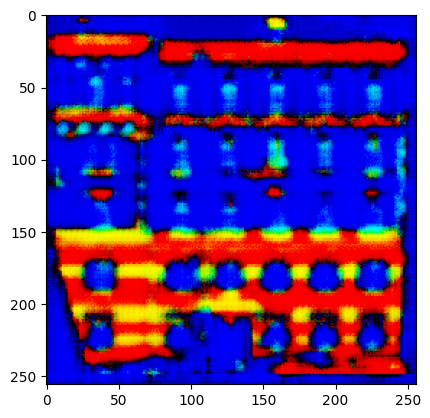

In [30]:
generator.eval()

sample,_ = train_dataset[0]

with torch.no_grad():

    output = generator(
        sample.unsqueeze(0).to(device)
    )

plt.imshow(
    output.squeeze()
    .permute(1,2,0)
    .cpu()
)
plt.show()

In [31]:
torch.save(
    generator.state_dict(),
    "pix2pix_generator.pth"
)

In [32]:
from torchvision.utils import save_image

save_image(
    output,
    "result.png"
)

In [33]:
from torchvision.utils import save_image

save_image(
    output,
    "result.png"
)